# **Introduction**

#De-Identification of DICOM Data - Jupyter Notebook Tutorial


**Authors:**
Nadia Farrag, Ph.D. &
Jefferson Casimir


This script-style Jupyter notebook introduces researchers to Python-based tools for reducing identifiability in DICOM data. It demonstrates common technical approaches used in de-identification workflows, with examples informed in part by the Information and Privacy Commissioner of Ontario (IPC) & HIPAA Safe Harbor concepts for identifiers commonly removed from health data.

> *This tutorial assumes a basic working knowledge of Python coding and familiarity with running Jupyter notebooks.*



## What this notebook demonstrates

- How to load a sample or custom DICOM file
- How to inspect DICOM metadata
- How to apply common metadata actions, including clearing, masking, generalization, pseudonymization, perturbation, and suppression
- How to review image pixels for burned-in identifiers
- How to save a modified DICOM file

## Before you start

On your first run, leave `USE_ARCHIMEDES_SAMPLE = True`. This loads the ARCHIMEDES sample MRI file and enables the sample ultrasound pixel-de-identification section.

If you set `USE_ARCHIMEDES_SAMPLE = False`, you must provide your own DICOM path in `CUSTOM_DICOM_PATH`. In that mode, the ultrasound section is skipped automatically because the ultrasound sample is loaded from the ARCHIMEDES GitHub sample data.


--------------

## **IMPORTANT DISCLAIMER:**

This tutorial is provided for **educational and research workflow support only**. It does not provide legal advice, and **it does not by itself determine whether data are de-identified, anonymized, or otherwise compliant under any specific law or institutional policy**. Users are responsible for ensuring that their data handling practices meet the requirements of the laws, regulations, ethics approvals, data sharing agreements, and institutional policies applicable to their project.

***For Canadian users:***

Methods commonly used to satisfy HIPAA de-identification standards are not automatically sufficient for data to be considered anonymized or non-identifiable under Canadian laws. In many Canadian contexts, data that have undergone HIPAA-style de-identification may still be treated as coded or potentially identifiable. Consult your institution, privacy office, REB, or legal/privacy experts where appropriate.

------------------------------------------

# How to use this notebook

Run the notebook from top to bottom.

Most users only need to edit **Section 1: One-step configuration**. The rest of the notebook is organized as a guided tutorial. Sections that are mainly helper code are labelled clearly so beginners know they do not need to edit them.

# Setup: Install and Import Necessary Libraries


Before running the notebook, some Python libraries may need to be installed and/or imported. *Installing* a library makes it available within your Python environment, while *importing* a library allows the notebook to actively use its functions within the code.

Some environments, such as Google Colab, already include commonly used libraries (e.g., NumPy and Matplotlib) pre-installed by default. Because of this, installation commands for those libraries are shown as commented lines (#) for reference only and do not need to be run in Colab. However, in a standard local Python environment, these libraries may need to be installed manually. This is typically done after creating and activating a virtual environment.

In contrast, pydicom is not included by default in many Python environments, so it must be installed before use. The exclamation mark (!) indicates that the command should be run as a system installation command within the notebook environment.

In [1]:
# -- Install libraries --
# In Google Colab, pydicom usually needs to be installed.
!pip install pydicom #the ! will be removed when taken off colab

# #Outside of Google Colab, you may need to install the following libraries (commented here as they are already installed by default on Colab)
# pip install numpy #--> commented until taken off of Colab
# pip install matplotlib #--> commented until taken off of Colab
# pip install pillow #--> commented until taken off of Colab
# pip install hashlib #--> commented until taken off of Colab
# pip install glob #--> commented until taken off of Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.7 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import pydicom
from pydicom.data import get_testdata_files
from pydicom.uid import generate_uid
from hashlib import sha256
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import glob
import random

# Helper functions used for displaying demos

You do not need to edit this section. These helper functions only make the outputs easier to read.

The code below creates helper functions used later in the notebook. These functions do not change or de-identify the DICOM file. They simply help display selected metadata fields before and after a de-identification step, so users can more easily confirm what changed.

For example, the helper functions allow DICOM tags to be entered using either their keyword name, such as `PatientName`, or their numeric tag, such as `(0010,0010)`.

In [3]:
# ---- Helper functions for displaying metadata before and after de-identification ----
# These functions do not modify the DICOM file.
# They are only used to make the tutorial outputs easier to read.

from pydicom.tag import Tag
from pydicom.datadict import tag_for_keyword, keyword_for_tag


def format_dicom_tag(tag_input):
    """
    Convert different DICOM tag formats into a standardized format that Python can read.

    DICOM metadata fields can be written in different ways, including:
    - A keyword name, such as "PatientName"
    - A hexadecimal tag number, such as "0010,0010"
    - A tuple format, such as (0x0010, 0x0010)

    Hexadecimal numbers are commonly used in DICOM metadata because each
    DICOM field is assigned a unique tag identifier.
    """

    # Try to interpret the input as a pydicom Tag
    try:
        return Tag(tag_input)
    except Exception:
        pass

    # If the tag is written as a tuple/list, such as (0x0010, 0x0010)
    if isinstance(tag_input, (tuple, list)) and len(tag_input) == 2:
        return Tag(int(tag_input[0]), int(tag_input[1]))

    # If the tag is written as text
    if isinstance(tag_input, str):

        # Try to interpret it as a DICOM keyword, such as "PatientName"
        tag_number = tag_for_keyword(tag_input)
        if tag_number is not None:
            return Tag(tag_number)

        # Try to interpret it as a hexadecimal tag number, such as "0010,0010"
        cleaned_tag = (
            tag_input
            .replace(",", "")
            .replace("(", "")
            .replace(")", "")
            .replace(" ", "")
            .lower()
        )

        if len(cleaned_tag) == 8 and all(c in "0123456789abcdef" for c in cleaned_tag):
            return Tag(int(cleaned_tag[:4], 16), int(cleaned_tag[4:], 16))

    raise ValueError(f"Unrecognized DICOM tag: {tag_input}")


def format_dicom_tag_label(tag):
    """
    Create a readable label for a DICOM tag.

    Example:
    (0010,0010) PatientName
    """

    tag = format_dicom_tag(tag)
    keyword = keyword_for_tag(tag) or ""
    return f"({tag.group:04X},{tag.element:04X}) {keyword}".strip()


def get_metadata_values(ds, tags):
    """
    Return the values for selected DICOM metadata fields.
    If a field is not present in the file, it will say '<not present>'.
    """

    values = {}

    for tag_input in tags:
        tag = format_dicom_tag(tag_input)
        label = format_dicom_tag_label(tag)

        if tag in ds:
            values[label] = str(ds[tag].value)
        else:
            values[label] = "<not present>"

    return values


def print_before_after(ds_before, ds_after, tags):
    """
    Print selected DICOM metadata values before and after a change.
    This helps users confirm whether a de-identification step worked as intended.
    """

    print("BEFORE:")
    for label, value in get_metadata_values(ds_before, tags).items():
        print(f"  {label}: {value}")

    print("\nAFTER:")
    for label, value in get_metadata_values(ds_after, tags).items():
        print(f"  {label}: {value}")

# 1. One-step Configuration

This is the main section users should edit.



> Choose **one** option:



| What you want to do | Setting |
|---|---|
| Use the ARCHIMEDES sample files | `USE_ARCHIMEDES_SAMPLE = True` |
| Use your own DICOM file | `USE_ARCHIMEDES_SAMPLE = False` and update `CUSTOM_DICOM_PATH` |

When `USE_ARCHIMEDES_SAMPLE = False`, the ultrasound section is skipped automatically because that section uses the ARCHIMEDES sample ultrasound file.

## 1A. Choose sample file or custome file

In [5]:
# ================================
# USER SETTINGS - EDIT THIS CELL ONLY
# ================================

# Option 1: Use the ARCHIMEDES sample DICOM files from GitHub.
# This is recommended for the first run.
USE_ARCHIMEDES_SAMPLE = True

# Option 2: Use your own DICOM file instead.
# If USE_ARCHIMEDES_SAMPLE = False, replace this with your uploaded file path.
# Example in Colab after drag-and-drop upload: "/content/my_file.dcm"
CUSTOM_DICOM_PATH = ""

# Output filename for the final de-identified DICOM file.
OUTPUT_DICOM_PATH = "deidentified_output.dcm"

## 1B. Load the selected DICOM file

In [6]:
# This cell uses the settings above to load either:
# 1) the ARCHIMEDES sample MRI file, or
# 2) the user's custom DICOM file.

import urllib.request

ARCHIMEDES_MRI_URL = "https://raw.githubusercontent.com/ARCHIMEDES-Data/Deidentification-Tutorials/main/src/sample_data/MRI_slice_1.dcm"
ARCHIMEDES_US_URL = "https://raw.githubusercontent.com/ARCHIMEDES-Data/Deidentification-Tutorials/main/src/sample_data/ultrasound_image1.dcm"

ARCHIMEDES_MRI_PATH = "/content/MRI_slice_1.dcm"
ARCHIMEDES_US_PATH = "/content/ultrasound_image1.dcm"

if USE_ARCHIMEDES_SAMPLE:
    urllib.request.urlretrieve(ARCHIMEDES_MRI_URL, ARCHIMEDES_MRI_PATH)
    urllib.request.urlretrieve(ARCHIMEDES_US_URL, ARCHIMEDES_US_PATH)

    dicom_path = ARCHIMEDES_MRI_PATH
    USE_ULTRASOUND_EXAMPLES = True
    print("Using ARCHIMEDES sample DICOM files.")

else:
    USE_ULTRASOUND_EXAMPLES = False

    if not CUSTOM_DICOM_PATH:
        raise ValueError(
            "USE_ARCHIMEDES_SAMPLE is set to False, but CUSTOM_DICOM_PATH is blank. "
            "Upload your DICOM file to Colab, then paste the file path into CUSTOM_DICOM_PATH."
        )

    if not os.path.exists(CUSTOM_DICOM_PATH):
        raise FileNotFoundError(
            f"CUSTOM_DICOM_PATH was not found: {CUSTOM_DICOM_PATH}. "
            "Check the file path and re-run this cell."
        )

    dicom_path = CUSTOM_DICOM_PATH
    print("Using custom DICOM file.")
    print("Ultrasound examples will be skipped for custom files.")

# Load one copy for processing and one untouched copy for comparison.
dicom_ds = pydicom.dcmread(dicom_path)
baseline_ds = pydicom.dcmread(dicom_path)

print(f"Loaded DICOM file: {dicom_path}")

Using ARCHIMEDES sample DICOM files.
Loaded DICOM file: /content/MRI_slice_1.dcm


## File loaded

The notebook now has two copies of the selected DICOM file:

- `dicom_ds`: the working copy used for de-identification examples
- `baseline_ds`: the untouched copy used for before/after comparisons

# 2. Example identifiers commonly considered during DICOM de-identification


One commonly cited framework is the HIPAA Safe Harbor method, which identifies 18 categories of identifiers that are typically removed from health data. For DICOM files, examples may include:

1. Names
2. Geographic subdivisions smaller than a state
3. All elements of dates (except year)
4. Telephone numbers
5. Fax numbers
6. Email addresses
7. Social Security numbers
8. Medical record numbers (MRN)
9. Health plan beneficiary numbers
10. Account numbers
11. Certificate/license numbers
12. Vehicle identifiers
13. Device identifiers
14. URLs
15. IP addresses
16. Biometric identifiers
17. Full-face photos or comparable images
18. Any unique identifying number, characteristic, or code

Some of these may correspond to DICOM metadata fields such as:
- (0010,0010) PatientName
- (0008,0081) InstitutionAddress
- (0008,0022) Acquisition Date
- (0040,1103) PersonsTelephoneNumbers
- (0010,0020) PatientID
- (0010,1000) OtherPatientIDs
- (0010,0030) PatientBirthDate
- (0008,0090) ReferringPhysicianName
- (0008,0080) InstitutionName
- (0008,1070) OperatorsName
- (0018,1000) DeviceSerialNumber
- ... and many more

This is not an exhaustive list. The metadata elements that should be reviewed or modified depend on the file content, project context, jurisdiction, and intended data use.

In this tutorial, the HIPAA Safe Harbor identifiers are used primarily as a simple and widely recognized educational framework to help demonstrate common types of potentially identifying information that may appear in DICOM data. However, Canadian privacy frameworks and provincial regulations may differ from U.S. approaches and do not necessarily define a fixed list of identifiers in the same way. Users should refer to their institutional policies, REB requirements, privacy offices, and applicable provincial/federal guidance when determining appropriate de-identification practices for their project.

# 3. Preview the Selected DICOM Image

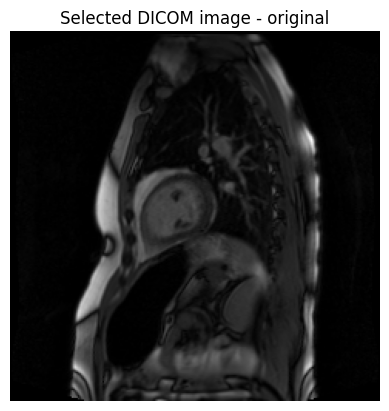

In [7]:
# Preview the selected DICOM image.
# This confirms that the file loaded correctly and contains image pixel data.

image_array = baseline_ds.pixel_array

plt.imshow(image_array, cmap="gray")
plt.title("Selected DICOM image - original")
plt.axis("off")
plt.show()

#4. Inspect DICOM Metadata

Review your DICOM file carefully for metadata fields that may contain direct identifiers (e.g., patient name or DOB), indirect identifiers (e.g., patient age or postal code), dates, site information, device information, or other elements that could contribute to re-identification risk.

A great resource to reference the entire DICOM metadata tag library can be found [here](https://www.dicomlibrary.com/dicom/dicom-tags/)

In [9]:
print("\n--- ALL METADATA BEFORE DE-IDENTIFICATION ---")

for elem in dicom_ds:
    # Skip large binary pixel data so the output stays readable.
    if elem.VR != "OB" and elem.tag.group != 0x7FE0:
        print(f"{elem.tag} {elem.name}: {elem.value}")


--- ALL METADATA BEFORE DE-IDENTIFICATION ---
(0008,0005) Specific Character Set: ISO_IR 100
(0008,0008) Image Type: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS2D', 'MFSPLIT']
(0008,0012) Instance Creation Date: 20251104
(0008,0013) Instance Creation Time: 120402.380000
(0008,0016) SOP Class UID: 1.2.840.10008.5.1.4.1.1.4
(0008,0018) SOP Instance UID: 1.3.12.2.1107.5.2.18.41999.30000025110412545190100000019
(0008,0020) Study Date: 20251104
(0008,0021) Series Date: 20251104
(0008,0022) Acquisition Date: 20251104
(0008,0023) Content Date: 20251104
(0008,002A) Acquisition DateTime: 20251104120359.797500
(0008,0030) Study Time: 120323.000000
(0008,0031) Series Time: 120353.955000
(0008,0032) Acquisition Time: 120359.797500
(0008,0033) Content Time: 120403.834000
(0008,0050) Accession Number: 
(0008,0060) Modality: MR
(0008,0070) Manufacturer: Siemens Healthineers
(0008,0080) Institution Name: Heart Institute
(0008,0081) Institution Address: Ruskin Street 40,Ottawa,Eastern,CA,k1Y 4W7
(0008,0

## Tags containing dates

Metadata tags containing dates may include fields such as:

*   Study date
*   Series date
*   Acquisition date
*   Content date
*   Patient birth date
*   ... and so on.

Some dates may be directly identifying on their own, while others may increase re-identification risk when combined with other information. The example below is not a complete list. DICOM files can contain many date-related attributes, so the original identified file should always be reviewed carefully.

**Please note:**
This is not an exhaustive list of DICOM tags containing dates. The DICOM standard is constantly evolving, and many metadata tags may contain dates. You should always carefully inspect your original (identified) image to determine all fields that contain dates, and then add them to the helper function to de-identify them.

In [11]:
example_date_tags = {
    (0x0008, 0x0020): "Study Date",
    (0x0008, 0x0021): "Series Date",
    (0x0008, 0x0022): "Acquisition Date",
    (0x0008, 0x0023): "Content Date",
    (0x0008, 0x0012): "Instance Creation Date",
    (0x0018, 0x1012): "Date of Secondary Capture", # May not exist in all files
    (0x0040, 0x0244): "Performed Procedure Step Start Date",  # May not exist in all files
    (0x0010, 0x0030): "Patient Birth Date"
}


#Show the output of the above-listed date tags.
print('Output of the original dicom file "example_date_tags":')
for tag, label in example_date_tags.items():
    if tag in baseline_ds:
        print(f"{label}: {baseline_ds[tag].value}")
    else:
        print(f"{label}: (not found)")

Output of the original dicom file "example_date_tags":
Study Date: 20251104
Series Date: 20251104
Acquisition Date: 20251104
Content Date: 20251104
Instance Creation Date: 20251104
Date of Secondary Capture: (not found)
Performed Procedure Step Start Date: 20251104
Patient Birth Date: 20251104


## Date handling tip

When modifying image acquisition/study dates, users should apply a consistent approach across related date fields rather than generalizing one date, clearing another, and shifting another.

For example, if study-related dates are shifted, they should generally be shifted together so that the temporal relationships between the study, series, acquisition, and image instances are preserved. This helps maintain internal consistency within the DICOM file and may reduce issues when opening the de-identified file in another viewer or research workflow.

Where dates are needed for longitudinal imaging, follow-up studies, or approved record linkage, avoid applying inconsistent transformations across related date fields.

#Mapping dictionary to define which DICOM tags to apply functions A-F.

### Choosing which de-identification action to apply

***The block of code underneath is intended to be edited and customized by the user based on their own dataset and project requirements.***

The configuration map below tells the notebook which action to apply to selected DICOM metadata fields. There is no single “best” action for every field. The appropriate choice depends on the type of information, whether the information is needed for analysis, the intended data use, and your institution’s policies.

In general:
- `clear` is useful when a field is not needed and can be removed.
- `mask` is useful when a field should be replaced with a generic placeholder, such as `REDACTED`.
- `generalize` is useful when partial information is needed, such as keeping only the year from a full date.
- `pseudonymize` is useful when identifiers need to be replaced with consistent coded values so records can still be linked within a project.
- `noise` is useful when dates or numeric values need to be shifted or perturbed while preserving some general structure.
- `pixel_masks` are used to cover burned-in identifiers that appear directly on the image pixels.

-----
***Important:*** If you need to link de-identified files back to the original records, this requires a secure key or **linkage file**. That key should be stored separately, protected according to institutional policy, and **never shared publicly.** If a linkage key is retained, the data may still be considered coded or potentially identifiable depending on the context and applicable policies.

In [42]:
DEID_MAP = {
    "clear": [
        # Best for fields that are not needed and can be removed entirely
        "OperatorsName",
        "InstitutionAddress",
        "PatientName",
    ],

    "mask": {
        # Best for fields that should be replaced with a generic placeholder
        "InstitutionName": "REDACTED HOSPITAL",
    },

    "generalize": {
        # Best for fields where less-specific information is still useful
        # Example: keep only the year from a full date
        "PatientBirthDate": "keep_year",
    },

    "pseudonymize": [
        # Best for identifiers that need to be replaced with consistent coded values
        # This supports linking records within a project without showing the original identifier
        "PatientID",
    ],

    "noise": {
        # Best for shifting or perturbing dates/numeric values
        # Example: shift StudyDate randomly within ±2 years
        "StudyDate": {"type": "date_shift", "range": 2},
    },

    "suppress_private": True,
    # Removes private DICOM elements when applying the plan

    "pixel_masks": [
        # Optional blackout boxes for burned-in identifiers in the image pixels
        # Format: [x1, y1, x2, y2]
        # Example: [5, 5, 200, 40],
    ],
}

# 5. Common de-identification techniques demonstrated in this notebook

This section demonstrates several technical strategies that can be applied to DICOM metadata. These examples are intended to illustrate common approaches used in research workflows. Whether a given approach is appropriate or sufficient depends on the data, project context, intended data use, applicable governance requirements, and institutional policies. Users should consult their institution, REB, privacy office, and relevant provincial/federal guidance where appropriate.

**Descriptions & Examples of Functions A-F are given below.**

# A. Direct Clearing of Tags


Direct clearing means removing selected metadata elements entirely. This can be useful when a field is known to contain a direct identifier or other information that is not needed for the intended research use.

See below the python function followed by the demo.

In [12]:
def clear_tags(dicom_ds, tags_to_clear):
    """
    This function removes selected DICOM metadata fields from the dataset.
    """
    for tag in tags_to_clear:
        T = format_dicom_tag(tag)
        if T in dicom_ds:
            del dicom_ds[T]
    return dicom_ds

Demo of Function A, Clearing:

In [14]:
_demoA_before = baseline_ds.copy()
_demoA_after = dicom_ds.copy()

_demoA_after = clear_tags(_demoA_after, ["InstitutionAddress"])

print("A) CLEAR example: remove InstitutionAddress and OperatorsName")
print_before_after(_demoA_before, _demoA_after, ["InstitutionAddress"])


A) CLEAR example: remove InstitutionAddress and OperatorsName
BEFORE:
  (0008,0081) InstitutionAddress: Ruskin Street 40,Ottawa,Eastern,CA,k1Y 4W7

AFTER:
  (0008,0081) InstitutionAddress: <not present>


# B. Masking / Replacing Tags with Generic Values

Masking replaces an original value with a generic placeholder such as “REDACTED” or “UNKNOWN.” The field remains present, but the original value is no longer shown.

See the python function below, followed by a demo.

In [15]:
def mask_tags(dicom_ds, replacements):
    """
    This function replaces selected DICOM metadata fields from the dataset
    with a generic placeholder.
    """
    for tag, value in replacements.items():
        T = format_dicom_tag(tag)

        if T in dicom_ds:
            dicom_ds[T].value = value

        else:
            # Optional: create the field if it does not already exist
            try:
                kw = keyword_for_tag(T)

                if kw:
                    setattr(dicom_ds, kw, value)

            except Exception:
                pass

    return dicom_ds

Demo of Function B, Masking:

In [16]:
_demoB_before = baseline_ds.copy()
_demoB_after = dicom_ds.copy()

_demoB_after = mask_tags(
    _demoB_after,
    {"InstitutionName": "REDACTED HOSPITAL"}
)

print("B) MASK example: InstitutionName → 'REDACTED HOSPITAL'")
print_before_after(
    _demoB_before,
    _demoB_after,
    ["InstitutionName"]
)

B) MASK example: InstitutionName → 'REDACTED HOSPITAL'
BEFORE:
  (0008,0080) InstitutionName: Heart Institute

AFTER:
  (0008,0080) InstitutionName: REDACTED HOSPITAL


# C. Generalization Example: Keeping only birth year

Generalization reduces specificity while retaining some analytic usefulness.

For general applications, generalization may involve "binning" data into broader ranges to reduce specificity - e.g., binning the age 43 into the range 40 - 45. However, in the DICOM Standard, we are unable to store data in ranges because attributes such as Date (DA) must follow a strict YYYYMMDD format.

A practical way to demonstrate generalization is to preserve only the birth year and replace the month and day with a dummy value. This reduces specificity as the exact birth date is hidden, while still retaining useful coarse information (the year of birth).

See the python function below, followed by a demo.

In [17]:
def generalize_date(dicom_ds, tag="PatientBirthDate", seed=None):
    """
    Keep the original year while replacing the month and day
    with randomly generated placeholder values.
    """

    if tag in dicom_ds and dicom_ds[tag].value:
        s = str(dicom_ds[tag].value)

        if len(s) >= 4 and s[:4].isdigit():
            r = random.Random(seed)

            mm = r.randint(1, 12)
            dd = r.randint(1, 27)

            dicom_ds[tag].value = f"{s[:4]}{mm:02d}{dd:02d}"

    return dicom_ds

Demo of Function C, Generalization:

In [18]:
_demoC_before = baseline_ds.copy()
_demoC_after = dicom_ds.copy()

_demoC_after = generalize_date(_demoC_after)

print("C) GENERALIZE example: keep birth year while replacing month/day")
print_before_after(
    _demoC_before,
    _demoC_after,
    ["PatientBirthDate"]
)

C) GENERALIZE example: keep birth year while replacing month/day
BEFORE:
  (0010,0030) PatientBirthDate: 20251104

AFTER:
  (0010,0030) PatientBirthDate: 20251107


# D. Perturbation

Perturbation means modifying values slightly so that exact original values are hidden while some analytic utility is preserved. In DICOM workflows, a common example is **shifting dates** by a random offset. This can help protect identifiable calendar dates while preserving relative timing within a study.

See below for a demo of **date shifting**.

In [19]:
from datetime import datetime, timedelta
import random

def shift_date(dicom_ds, tag="StudyDate", max_shift_days=90):
    """
    Randomly shift a DICOM date forward or backward by a selected number of days.

    The output remains in valid YYYYMMDD DICOM date format.
    """

    if tag in dicom_ds and dicom_ds[tag].value:

        try:
            original = str(dicom_ds[tag].value)

            dt = datetime.strptime(original, "%Y%m%d")

            offset = random.randint(-max_shift_days, max_shift_days)

            new_dt = dt + timedelta(days=offset)

            dicom_ds[tag].value = new_dt.strftime("%Y%m%d")

        except Exception:
            pass  # Skip invalid or non-standard date formats

    return dicom_ds

Demo of Function D, Perturbation applied to dates (Date Shifting):

In [20]:
_demoD_before = baseline_ds.copy()
_demoD_after = dicom_ds.copy()

shift_date(_demoD_after, tag="StudyDate", max_shift_days=90)

print("D) DATE SHIFT example: randomly shift StudyDate by up to ±90 days")

print_before_after(
    _demoD_before,
    _demoD_after,
    ["StudyDate"]
)


D) DATE SHIFT example: randomly shift StudyDate by up to ±90 days
BEFORE:
  (0008,0020) StudyDate: 20251104

AFTER:
  (0008,0020) StudyDate: 20260127


# E. Pseudonymization: coded patient ID

Pseudonymization replaces an identifier with a consistent coded value, such as a hash. The same input produces the same pseudonym, which can support linkage across records without revealing the original value directly.

Pseudonymized data may still be considered identifiable, depending on whether re-linkage is possible and how the keying or coding process is governed.

See below for a demo.

In [21]:
from hashlib import sha256


def generate_pseudonym(value):
    """
    Convert an identifier into a pseudonymized code using SHA-256 hashing.

    The original value is replaced with a shortened hash value
    that can help reduce direct identifiability.
    """

    return sha256(str(value).encode()).hexdigest()[:12]

Demo of Function E, Pseudonymization:

In [22]:
_demoE_before = baseline_ds.copy()
_demoE_after = dicom_ds.copy()

if "PatientID" in _demoE_after:
    _demoE_after.PatientID = generate_pseudonym(
        _demoE_after.PatientID
    )

print("E) PSEUDONYMIZE example: PatientID → pseudonymized hash")

print_before_after(
    _demoE_before,
    _demoE_after,
    ["PatientID"]
)

E) PSEUDONYMIZE example: PatientID → pseudonymized hash
BEFORE:
  (0010,0020) PatientID: TEST_04Nov2025

AFTER:
  (0010,0020) PatientID: f923418fc08a


# F. Suppression: removing fields that may increase identification risk

Suppression is a general de-identification technique in which data elements are removed so they cannot be used directly or indirectly to identify an individual. In practice, suppression may be applied in different ways, such as:


*   Broad removal of categories of fields that may contain identifying content, such as private DICOM elements

*   Selective removal of fields whose presence may increase re-identification risk in a particular context



In this notebook, suppression is demonstrated by removing private DICOM elements. This is presented as a general technical strategy used in de-identification workflows. It is not intended to suggest that “suppression” is a formally defined HIPAA term. Rather, HIPAA interpretive guidance discusses the removal of identifiers and the need to reduce the risk that individuals can be identified from the remaining data.

We separate suppression here from direct clearing by scope:

*   direct clearing removes specific known fields selected by the user

*   suppression removes broader groups of fields or fields that may become identifying in context

----


See below for a demo.

In [23]:
def suppress_private(dicom_ds):
    """
    Remove private DICOM metadata elements.

    In DICOM files, private/vendor-specific fields are commonly stored
    in odd-numbered groups. These fields may contain additional
    identifying or institution-specific information.
    """

    tags_to_remove = []

    for tag in list(dicom_ds.keys()):

        # Private DICOM elements are typically stored in odd-numbered groups
        if tag.group % 2 != 0:
            tags_to_remove.append(tag)

    for tag in tags_to_remove:
        del dicom_ds[tag]

    return dicom_ds

Demo of function F, Suppression:

In [24]:
_demoF = dicom_ds.copy()

# Count private elements before suppression
n_before = sum(1 for e in _demoF if e.tag.group % 2 == 1)

# Remove private elements
_demoF = suppress_private(_demoF)

# Count remaining private elements
n_after = sum(1 for e in _demoF if e.tag.group % 2 == 1)

print(f"F) SUPPRESS example: private DICOM elements {n_before} → {n_after}")


F) SUPPRESS example: private DICOM elements 97 → 0


# 8. Handling Burned-in Annotations in Pixel Data

Some DICOM files contain identifying information directly in the image pixels rather than only in the metadata. Examples may include patient names, accession numbers, dates, or site identifiers burned into the image.

Two possible strategies:
1. Masking using black boxes
2. Cropping the image

Pixel-based identifiers should be reviewed carefully, especially in modalities such as ultrasound or secondary capture images. Please note in volumetric and/or video data, ***every*** slice needs to be carefully checked for residual burned-in text identifiers.

In [ ]:
if not USE_ULTRASOUND_EXAMPLES:

    print("Ultrasound examples are only available when using the ARCHIMEDES sample images.")

else:

  US_path = "/content/ultrasound_image1.dcm"

  # Load the ultrasound DICOM file
  us_ds = pydicom.dcmread(US_path)

  # Create an untouched copy for before/after demonstrations
  us_ds_baseline = pydicom.dcmread(US_path)

## 8A. Show Original Ultrasound Image

In [25]:
if not USE_ULTRASOUND_EXAMPLES:
    print("Skipping ultrasound examples because USE_ARCHIMEDES_SAMPLE = False.")
else:
    # Load the ARCHIMEDES sample ultrasound DICOM file.
    ultrasound_ds = pydicom.dcmread(ARCHIMEDES_US_PATH)

    # Create an untouched copy for before/after demonstrations.
    ultrasound_baseline_ds = pydicom.dcmread(ARCHIMEDES_US_PATH)

    print("ARCHIMEDES sample ultrasound file loaded.")


ARCHIMEDES sample ultrasound file loaded.


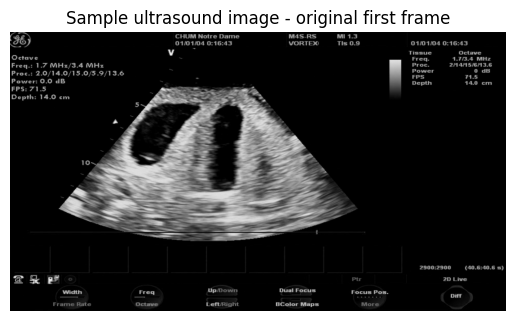

In [29]:
# Display one frame from the original ultrasound sample.

if not USE_ULTRASOUND_EXAMPLES:
    print("Skipping ultrasound examples because USE_ARCHIMEDES_SAMPLE = False.")
else:
    ultrasound_array = ultrasound_baseline_ds.pixel_array

    # Multi-frame/video DICOM files may have shape:
    # frames x rows x columns x colour channels.
    # For display, we show the first frame only.
    if ultrasound_array.ndim == 4:
        frame_to_show = ultrasound_array[:,:,:,0]
    elif ultrasound_array.ndim == 3:
        frame_to_show = ultrasound_array[:,:,0]
    else:
        frame_to_show = ultrasound_array

    plt.imshow(frame_to_show, cmap="gray")
    plt.title("Sample ultrasound image - original first frame")
    plt.axis("off")
    plt.show()

In [33]:
# ---- Pixel-based de-identification helper functions ----
# These examples demonstrate simple approaches for removing
# burned-in identifiers from image pixels.


def crop_pixels(dicom_ds, start_row):
    """
    Crop the top portion of a DICOM image.

    Works for:
    - Single-frame grayscale images: rows x columns
    - Multi-frame/video grayscale images: frames x rows x columns
    - Multi-frame/video colour images: frames x rows x columns x colour channels
    """

    if "PixelData" not in dicom_ds:
        return None

    pixels = dicom_ds.pixel_array

    if pixels.ndim == 2:
        return pixels[start_row:, :]

    if pixels.ndim == 3:
        return pixels[:, start_row:, :]

    if pixels.ndim == 4:
        return pixels[:, start_row:, :, :]

    raise ValueError(f"Unexpected pixel array shape: {pixels.shape}")


def blackout_region(dicom_ds, x1, y1, x2, y2):
    """
    Apply a black box over a selected image region.

    Coordinates are entered as:
    - x1 = left edge
    - y1 = top edge
    - x2 = right edge
    - y2 = bottom edge

    For multi-frame/video data, the same black box is applied to every frame.
    """

    if "PixelData" not in dicom_ds:
        return None

    pixels = dicom_ds.pixel_array.copy()

    if pixels.ndim == 2:
        pixels[y1:y2, x1:x2] = 0

    elif pixels.ndim == 3:
        pixels[:, y1:y2, x1:x2] = 0

    elif pixels.ndim == 4:
        pixels[:, y1:y2, x1:x2, :] = 0

    else:
        raise ValueError(f"Unexpected pixel array shape: {pixels.shape}")

    return pixels


def show_first_frame(pixel_array, title):
    """
    Display a single representative frame from an image or video array.
    This keeps multi-frame/video outputs readable in the notebook.
    """

    if pixel_array.ndim in [3, 4]:
        image_to_show = pixel_array[:,:,0]
    else:
        image_to_show = pixel_array

    plt.imshow(image_to_show, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


In [31]:
# USER INPUT: Adjust this value depending on where burned-in text appears
CROP_START_ROW = 71

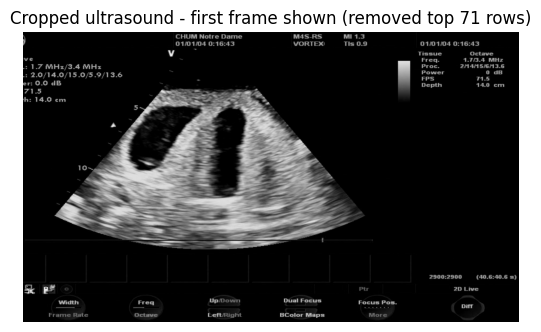

In [34]:
# ---- Example: crop the top portion of the sample ultrasound image/video ----

if not USE_ULTRASOUND_EXAMPLES:
    print("Skipping ultrasound examples because USE_ARCHIMEDES_SAMPLE = False.")
else:
    if "PixelData" in ultrasound_ds:
        cropped_pixels = crop_pixels(ultrasound_ds, CROP_START_ROW)

        show_first_frame(
            cropped_pixels,
            f"Cropped ultrasound - first frame shown (removed top {CROP_START_ROW} rows)"
        )

## 8B. Multi-frame data (multi-slice or video)

Many DICOM datasets contain more than one image per acquisition. For example, CT and MRI studies are often volumetric acquisitions containing multiple image slices across a larger anatomical volume, while ultrasound imaging is commonly stored as multi-frame/video data. Depending on the imaging modality, vendor, software version, and acquisition format, these images may be stored either as multiple individual DICOM files within a folder (e.g., one file per slice/frame) or as a single multi-frame DICOM file containing all slices/frames together.


In all cases, **all slices and frames should be carefully reviewed** for potentially identifying information, including burned-in text within the pixel data. **If cropping or black-box masking is applied, it should be applied to all relevant slices/frames in the acquisition rather than only a single image**.

Users should always inspect the output carefully before saving, sharing, or publishing de-identified files and should refer to their institutional policies and governance requirements where appropriate.

In [36]:
### Pixel de-identification for multi-frame/video DICOM data
# The crop_pixels() function above already handles both single-frame and multi-frame/video DICOM files.
# This alias is included to make the video/multi-frame use case explicit.

def crop_all_frames(dicom_ds, start_row):
    """
    Crop the top portion of every frame in a DICOM image or video.
    """
    return crop_pixels(dicom_ds, start_row)

In [37]:
def apply_cropped_pixels_to_dicom(dicom_ds, cropped_pixels):
    """
    Replace the DICOM pixel data with cropped pixel data.

    This updates the PixelData, Rows, and Columns fields so the file
    remains consistent with the new cropped image size.
    """

    dicom_ds.PixelData = cropped_pixels.tobytes()

    # Rows and columns are always the last image height/width dimensions
    if cropped_pixels.ndim == 2:
        dicom_ds.Rows, dicom_ds.Columns = cropped_pixels.shape

    elif cropped_pixels.ndim == 3:
        dicom_ds.Rows, dicom_ds.Columns = cropped_pixels.shape[1], cropped_pixels.shape[2]

    elif cropped_pixels.ndim == 4:
        dicom_ds.Rows, dicom_ds.Columns = cropped_pixels.shape[1], cropped_pixels.shape[2]

    return dicom_ds

# 9. Process and Save Your De-identified File

###9A. Apply the mapping table to de-id selected metadata tags.

Note:
Applying these transformations does not on its own guarantee that the output file is non-identifiable under any specific legal or institutional standard. Always review both metadata and pixel data, assess residual re-identification risk, and validate the output before sharing or publishing.

In [43]:
# === Apply the DEID_MAP plan ===
# This function applies the actions selected in the DEID_MAP configuration section above.

def apply_plan(dicom_ds, plan):

    # A) Clear selected fields
    if plan.get("clear"):
        dicom_ds = clear_tags(dicom_ds, plan["clear"])

    # B) Mask selected fields
    if plan.get("mask"):
        dicom_ds = mask_tags(dicom_ds, plan["mask"])

    # C) Generalize selected date fields
    if plan.get("generalize"):
        for tag, action in plan["generalize"].items():
            if action == "keep_year":
                dicom_ds = generalize_date(dicom_ds, tag=tag)

    # D) Shift or perturb selected date fields
    if plan.get("noise"):
        for tag, settings in plan["noise"].items():
            if settings.get("type") == "date_shift":
                max_shift = settings.get("range", 90)
                dicom_ds = shift_date(dicom_ds, tag=tag, max_shift_days=max_shift)

    # E) Pseudonymize selected fields
    if plan.get("pseudonymize"):
        for tag in plan["pseudonymize"]:
            T = format_dicom_tag(tag)

            if T in dicom_ds:
                dicom_ds[T].value = generate_pseudonym(dicom_ds[T].value)

    # F) Suppress private DICOM elements
    if plan.get("suppress_private"):
        dicom_ds = suppress_private(dicom_ds)

    # G) Apply pixel masks for burned-in identifiers
    if plan.get("pixel_masks") and "PixelData" in dicom_ds:
        arr = dicom_ds.pixel_array.copy()

        for x1, y1, x2, y2 in plan["pixel_masks"]:
            arr[y1:y2, x1:x2] = 0

        dicom_ds.PixelData = arr.tobytes()
        dicom_ds.Rows, dicom_ds.Columns = arr.shape[:2]

    return dicom_ds


In [44]:
# Apply the de-identification plan to a copy of the DICOM file.
dicom_plan_ds = dicom_ds.copy()
dicom_plan_ds = apply_plan(dicom_plan_ds, DEID_MAP)

# Preview selected fields after applying the plan.
print("AFTER applying DEID_MAP (sample of fields):")

for label, value in get_metadata_values(
    dicom_plan_ds,
    ["PatientID", "PatientName", "PatientBirthDate", "StudyDate", "InstitutionName"]
).items():
    print(f"  {label}: {value}")

AFTER applying DEID_MAP (sample of fields):
  (0010,0020) PatientID: 32f647e6aef0
  (0010,0010) PatientName: <not present>
  (0010,0030) PatientBirthDate: 20251014
  (0008,0020) StudyDate: 20260129
  (0008,0080) InstitutionName: REDACTED HOSPITAL


# Save your de-identified file

In [45]:
# Save the de-identified DICOM file.
# To change the filename, edit OUTPUT_DICOM_PATH in Section 1.

dicom_plan_ds.save_as(OUTPUT_DICOM_PATH)

print(f"\nSaved de-identified DICOM to: {OUTPUT_DICOM_PATH}")


Saved de-identified DICOM to: deidentified_output.dcm


In [46]:
# Apply cropped pixel data to the sample ultrasound DICOM file and save.

if not USE_ULTRASOUND_EXAMPLES:
    print("Skipping ultrasound examples because USE_ARCHIMEDES_SAMPLE = False.")
else:
    ultrasound_cropped_ds = ultrasound_ds.copy()

    cropped_frames = crop_all_frames(ultrasound_cropped_ds, CROP_START_ROW)

    ultrasound_cropped_ds = apply_cropped_pixels_to_dicom(
        ultrasound_cropped_ds,
        cropped_frames
    )

    # Optional: save cropped DICOM.
    ultrasound_output_path = "deidentified_ultrasound_output.dcm"
    ultrasound_cropped_ds.save_as(ultrasound_output_path)

    print(f"Saved cropped ultrasound DICOM to: {ultrasound_output_path}")


Saved cropped ultrasound DICOM to: deidentified_ultrasound_output.dcm


/usr/local/lib/python3.12/dist-packages/pydicom/pixels/decoders/base.py:801: UserWarning: The number of bytes of pixel data is sufficient to contain 360 frames which is larger than the given (0028,0008) 'Number of Frames' value of 1. The returned data will include these extra frames and if it's correct then you should update 'Number of Frames' accordingly, otherwise pass 'allow_excess_frames=False' to return only the first 1 frames.
  warn_and_log(


# 10. Final Notes and Resources

Other useful tools/libraries:
- `dicom-anonymizer` (https://pypi.org/project/dicom-anonymizer/)
- `pyminc`, `nibabel` for NIfTI conversions
- `dcm2niix` (command-line tool for research pipelines)
- `pynetdicom` for secure DICOM transfer

-----
Always validate and review output files before saving, sharing, or publishing them. De-identification should include review of both metadata and pixel data. Users should:


*   Verify that intended metadata fields/tags were properly modified or removed

*   Review all remaining metadata fields for residual identifying information


*   Preview images to check for burned-in text or identifiers within the pixel data

*   Confirm that the transformations applied are appropriate for the project context, intended data use, governance requirements, institutional policies, and jurisdiction







For projects involving Canadian data, remember that technical de-identification steps alone may not be enough for data to be considered anonymized or non-identifiable under law or institutional policy.

# References & Acknowledgements

This tutorial makes use of several open-source Python libraries and tools, including:

**Python libraries/packages:**
*   pydicom — https://pydicom.github.io/
*   NumPy — https://numpy.org/
*   Matplotlib — https://matplotlib.org/
*   Pillow (PIL) — https://python-pillow.org/
*   hashlib (Python Standard Library) — https://docs.python.org/3/library/hashlib.html


**Additional DICOM/de-identification resources referenced:**
*   DICOM Standard — https://www.dicomstandard.org/
*   Information and Privacy Commissioner of Ontario (IPC) De-Identification Guidelines - https://www.ipc.on.ca/en/resources/de-identification-guidelines-structured-data
*   Personal Information Protection and Electronic Documents Act (PIPEDA) - https://www.priv.gc.ca/en/privacy-topics/privacy-laws-in-canada/the-personal-information-protection-and-electronic-documents-act-pipeda/
*   HIPAA Safe Harbor Guidance — https://www.hhs.gov/hipaa/for-professionals/privacy/special-topics/de-identification/index.html


----

Acknowledgement:
This notebook was developed as part of educational and de-identification resource initiatives associated with the ARCHIMEDES platform.